In [3]:
from rdkit.Chem import PandasTools
import numpy as np
import pandas as pd
from rdkit import DataStructs
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle
import random
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import LeaveOneOut
from sklearn import preprocessing
# from genetic_selection import GeneticSelectionCV
from mordred import Calculator, descriptors

#  Функции для сбора дескрипторов

In [4]:
def calculate_descriptors_for_molecule(smiles, prefix=""):
    """
    Рассчитывает дескрипторы Mordred для одного SMILES
    Возвращает dict с дескрипторами или None если ошибка
    """
    if pd.isna(smiles):
        return None
        
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None
            
        # Создаем 3D структуру
        mol_3d = Chem.AddHs(mol)
        Chem.EmbedMolecule(mol_3d, randomSeed=0xf006d)
        
        try:
            Chem.MMFFOptimizeMolecule(mol_3d)
        except:
            pass
            
        # Рассчитываем дескрипторы
        calc = Calculator(descriptors)
        desc_dict = calc(mol_3d)
        
        # СОХРАНЯЕМ NaN значения 
        numeric_descriptors = {}
        for key, value in desc_dict.items():
            try:
                float_value = float(value)
                numeric_descriptors[f"{prefix}{key}"] = float_value
                # Сохраняем ВСЕ числа, включая nan и inf
            except (ValueError, TypeError):
                # Отсеиваем только настоящие ошибки
                continue
                
        return numeric_descriptors
        
    except Exception as e:
        print(f"Ошибка для SMILES {smiles}: {e}")
        return None

In [5]:
def process_reactions(data):
    """
    Обрабатывает все реакции и возвращает DataFrame с дескрипторами
    """
    all_descriptors = []
    
    for idx, reaction_smiles in enumerate(data['SMILES']):
        if pd.isna(reaction_smiles):
            all_descriptors.append({})
            continue
        
        print(f"Обработка реакции {idx+1}/{len(data)}: {reaction_smiles}")
        
        reaction_descriptors = {}
        
        if '>>' in str(reaction_smiles):
            # Разделяем на реагенты и продукты
            reagents_part, products_part = reaction_smiles.split('>>')
            
            # Обрабатываем реагенты
            reagents = [r.strip() for r in reagents_part.split('.') if r.strip()]
            for i, reagent in enumerate(reagents):
                prefix = f"reagent{i+1}_"
                desc_dict = calculate_descriptors_for_molecule(reagent, prefix)
                if desc_dict:
                    reaction_descriptors.update(desc_dict)
            
            # Обрабатываем продукты
            products = [p.strip() for p in products_part.split('.') if p.strip()]
            for i, product in enumerate(products):
                prefix = f"product{i+1}_"
                desc_dict = calculate_descriptors_for_molecule(product, prefix)
                if desc_dict:
                    reaction_descriptors.update(desc_dict)
                    
        # else:
        #     # Одиночная молекула - считаем и реагентом и продуктом
        #     prefix_reag = "reagent1_"
        #     desc_dict_reag = calculate_descriptors_for_molecule(reaction_smiles, prefix_reag)
        #     if desc_dict_reag:
        #         reaction_descriptors.update(desc_dict_reag)
            
        #     prefix_prod = "product1_"
        #     desc_dict_prod = calculate_descriptors_for_molecule(reaction_smiles, prefix_prod)
        #     if desc_dict_prod:
        #         reaction_descriptors.update(desc_dict_prod)
        
        all_descriptors.append(reaction_descriptors)
    
    return all_descriptors

# Укомплектовываем данные 

In [6]:
# Загружаем данные
data = pd.read_csv("../data/dfsmile.csv", index_col=False)
if 'Unnamed: 0' in data.columns:
    data.drop('Unnamed: 0', axis=1, inplace=True)
print(f"Загружено реакций: {len(data)}")

Загружено реакций: 69


In [7]:
data

,input,output,a,b,SMILES
0,1a+2a,3aa,14,36,C(CC=C)CCCC.[SiH](CC)(CC)CC>>C(CC[Si](CC)(CC)C...
1,1a+2b,3ab,53,55,C(CC=C)CCCC.[SiH](C)(C)c1ccccc1>>C(CC[Si](C)(C...
2,1a+2c,3ac,67,58,C(CC=C)CCCC.[SiH](c1ccccc1)(C)c1ccccc1>>C(CC[S...
3,1a+2d,3ad,89,96,C(CC=C)CCCC.[SiH](c1ccccc1)(c1ccccc1)c1ccccc1>...
4,1a+2e,3ae,96,99,C(CC=C)CCCC.[SiH]([Si](C)(C)C)([Si](C)(C)C)[Si...
...,...,...,...,...,...
64,1u+2c,3uc,30,29,C(C=C)N([Si](C)(C)C)[Si](C)(C)C.[SiH](c1ccccc1...
65,1u+2d,3ud,43,36,C(C=C)N([Si](C)(C)C)[Si](C)(C)C.[SiH](c1ccccc1...
66,1u+2e,3ue,72,0,C(C=C)N([Si](C)(C)C)[Si](C)(C)C.[SiH]([Si](C)(...
67,1v+2e,3ve,93,90,C(C=C)NC(=O)OC(C)(C)C.[SiH]([Si](C)(C)C)([Si](...


In [8]:
# data.drop([17, 16], inplace=True)
# data.reset_index(drop=True)

In [9]:
# Обрабатываем все реакции
print("Начинаем расчет дескрипторов...")
all_descriptors_list = process_reactions(data)

# Создаем DataFrame из дескрипторов
descriptors_df = pd.DataFrame(all_descriptors_list)

# Объединяем с исходными данными
result_df = pd.concat([data, descriptors_df], axis=1)

print("Обработка завершена!")
print(f"Итоговый размер: {result_df.shape}")

# Сохраняем результат
result_df.to_csv('reactions_with_descriptors_fixed.csv', index=False)
print("Результат сохранен в 'reactions_with_descriptors_fixed.csv'")

# Анализ результата
desc_columns = [col for col in result_df.columns if any(x in col for x in ['reagent', 'product'])]
print(f"Колонок с дескрипторами: {len(desc_columns)}")
print(f"Заполненных значений: {result_df[desc_columns].count().sum()}")
print(f"Процент заполнения: {result_df[desc_columns].count().sum() / (len(result_df) * len(desc_columns)) * 100:.2f}%")

Начинаем расчет дескрипторов...
Обработка реакции 1/69: C(CC=C)CCCC.[SiH](CC)(CC)CC>>C(CC[Si](CC)(CC)CC)CCCCC
Обработка реакции 2/69: C(CC=C)CCCC.[SiH](C)(C)c1ccccc1>>C(CC[Si](C)(C)c1ccccc1)CCCCC
Обработка реакции 3/69: C(CC=C)CCCC.[SiH](c1ccccc1)(C)c1ccccc1>>C(CC[Si](c1ccccc1)(C)c1ccccc1)CCCCC
Обработка реакции 4/69: C(CC=C)CCCC.[SiH](c1ccccc1)(c1ccccc1)c1ccccc1>>C(CC[Si](c1ccccc1)(c1ccccc1)c1ccccc1)CCCCC
Обработка реакции 5/69: C(CC=C)CCCC.[SiH]([Si](C)(C)C)([Si](C)(C)C)[Si](C)(C)C>>C(CC[Si]([Si](C)(C)C)([Si](C)(C)C)[Si](C)(C)C)CCCCC
Обработка реакции 6/69: C(CC=C)CCCC.[SiH](C)(C)O[Si](CCCCCCCC)(C)C>>C(CC[Si](C)(C)O[Si](CCCCCCCC)(C)C)CCCCC
Обработка реакции 7/69: C(CC=C)CCCC.[SiH](O[Si](C)(C)C)(O[Si](C)(C)C)C>>C(CC[Si](O[Si](C)(C)C)(O[Si](C)(C)C)C)CCCCC
Обработка реакции 8/69: C(CC=C)CCCC.[SiH](O[Si](O[Si](C)(C)C)(O[Si](C)(C)C)C)(O[Si](O[Si](C)(C)C)(O[Si](C)(C)C)C)C>>[Si](O[Si](O[Si](C)(C)C)(O[Si](C)(C)C)C)(O[Si](O[Si](C)(C)C)(O[Si](C)(C)C)C)(CCCCCCCC)C
Обработка реакции 9/69: C(CC=C

# Получаем все дескрипторы из mordred

In [10]:
result_df

,input,output,a,b,SMILES,reagent1_ABC,reagent1_ABCGG,reagent1_nAcid,reagent1_nBase,reagent1_SpAbs_A,...,product1_SRW10,product1_TSRW10,product1_MW,product1_AMW,product1_WPath,product1_WPol,product1_Zagreb1,product1_Zagreb2,product1_mZagreb1,product1_mZagreb2
0,1a+2a,3aa,14,36,C(CC=C)CCCC.[SiH](CC)(CC)CC>>C(CC[Si](CC)(CC)C...,NaN,NaN,0.0,0.0,9.517541,...,8.985821,45.252219,228.227328,4.855901,456.0,18.0,60.0,64.0,6.562500,4.000000
1,1a+2b,3ab,53,55,C(CC=C)CCCC.[SiH](C)(C)c1ccccc1>>C(CC[Si](C)(C...,NaN,NaN,0.0,0.0,9.517541,...,9.325899,48.607448,248.196027,5.515467,632.0,20.0,76.0,82.0,6.173611,4.041667
2,1a+2c,3ac,67,58,C(CC=C)CCCC.[SiH](c1ccccc1)(C)c1ccccc1>>C(CC[S...,NaN,NaN,0.0,0.0,9.517541,...,9.817766,55.491378,310.211677,5.965609,1143.0,31.0,104.0,118.0,6.534722,5.208333
3,1a+2d,3ad,89,96,C(CC=C)CCCC.[SiH](c1ccccc1)(c1ccccc1)c1ccccc1>...,NaN,NaN,0.0,0.0,9.517541,...,10.167735,61.874837,372.227328,6.308938,1794.0,42.0,132.0,154.0,6.895833,6.375000
4,1a+2e,3ae,96,99,C(CC=C)CCCC.[SiH]([Si](C)(C)C)([Si](C)(C)C)[Si...,NaN,NaN,0.0,0.0,9.517541,...,10.264687,55.243428,360.252008,5.542339,936.0,36.0,102.0,118.0,12.000000,4.562500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1u+2c,3uc,30,29,C(C=C)N([Si](C)(C)C)[Si](C)(C)C.[SiH](c1ccccc1...,NaN,NaN,0.0,0.0,12.129426,...,10.262734,61.142249,399.223380,6.336879,1651.0,41.0,134.0,154.0,10.770833,5.541667
65,1u+2d,3ud,43,36,C(C=C)N([Si](C)(C)C)[Si](C)(C)C.[SiH](c1ccccc1...,NaN,NaN,0.0,0.0,12.129426,...,10.500592,67.165647,461.239030,6.589129,2458.0,52.0,162.0,190.0,11.131944,6.708333
66,1u+2e,3ue,72,0,C(C=C)N([Si](C)(C)C)[Si](C)(C)C.[SiH]([Si](C)(...,NaN,NaN,0.0,0.0,12.129426,...,10.571035,60.644760,449.263710,5.911365,1384.0,46.0,132.0,154.0,16.236111,4.895833
67,1v+2e,3ve,93,90,C(C=C)NC(=O)OC(C)(C)C.[SiH]([Si](C)(C)C)([Si](...,NaN,NaN,0.0,0.0,11.631274,...,10.402959,59.068001,405.237086,6.048315,1379.0,40.0,122.0,139.0,14.673611,4.854167


# Достаточно много полностью пустых столбцов

In [11]:
# Самый простой способ - удалить совсем пустые столбцы
desc_columns = [col for col in result_df.columns if any(x in col for x in ['reagent', 'product'])]
empty_cols = result_df[desc_columns].columns[result_df[desc_columns].isna().all()].tolist()

print(f"Полностью пустых столбцов: {len(empty_cols)}")
cleaned_df = result_df.drop(columns=empty_cols)
print(f"Осталось столбцов: {len(cleaned_df.columns)}")

Полностью пустых столбцов: 954
Осталось столбцов: 4529


# А частично пустых не так много, поэтому их можно удалить, наверняка самые важные дескрипторы останутся

In [12]:
# Удаляем все столбцы, где есть хотя бы одно пустое значение
initial_columns = len(result_df.columns)
print(f"Исходное количество столбцов: {initial_columns}")

# Удаляем столбцы с любыми NaN значениями
cleaned_df = result_df.dropna(axis=1)
final_columns = len(cleaned_df.columns)
print(f"Количество столбцов после удаления: {final_columns}")
print(f"Удалено столбцов: {initial_columns - final_columns}")
print(f"Сохранено: {final_columns} столбцов")

Исходное количество столбцов: 5483
Количество столбцов после удаления: 4127
Удалено столбцов: 1356
Сохранено: 4127 столбцов


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def complete_pca_analysis_with_parity(df, target_column, n_components_range=None):
    """
    Полный PCA анализ для малого набора данных (69 строк)
    """
    if n_components_range is None:
        n_components_range = [10, 20, 30, 40, 60]
    
    print("=" * 70)
    print("ПОЛНЫЙ PCA АНАЛИЗ ДЛЯ МАЛОГО НАБОРА ДАННЫХ (69 СТРОК)")
    print("=" * 70)
    
    # 1. ПОДГОТОВКА ДАННЫХ
    print("\n1. ПОДГОТОВКА ДАННЫХ")
    print("-" * 40)
    
    # Отделяем целевую переменную
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    # Выбираем только дескрипторы
    desc_columns = [col for col in X.columns if any(x in col for x in ['reagent', 'product'])]
    X_desc = X[desc_columns]
    
    print(f"Всего строк: {X_desc.shape[0]}")
    print(f"Всего признаков: {X_desc.shape[1]}")
    print(f"Целевая переменная: {target_column}")
    
    # 2. МАСШТАБИРОВАНИЕ
    print("\n2. МАСШТАБИРОВАНИЕ ПРИЗНАКОВ")
    print("-" * 40)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_desc)
    
    print("Масштабирование завершено")
    print(f"Среднее после масштабирования: {np.mean(X_scaled):.2f}")
    print(f"Стандартное отклонение: {np.std(X_scaled):.2f}")

    # 3. АНАЛИЗ ОБЪЯСНЕННОЙ ДИСПЕРСИИ
    print("\n3. АНАЛИЗ ОБЪЯСНЕННОЙ ДИСПЕРСИИ PCA")
    print("-" * 40)
    
    # Сначала делаем PCA с максимальным количеством компонент для анализа
    pca_full = PCA().fit(X_scaled)
    explained_variance_full = np.cumsum(pca_full.explained_variance_ratio_)
    
    # Находим сколько компонент нужно для 80%, 90%, 95% дисперсии
    n_80 = np.argmax(explained_variance_full >= 0.80) + 1
    n_90 = np.argmax(explained_variance_full >= 0.90) + 1
    n_95 = np.argmax(explained_variance_full >= 0.95) + 1
    
    print(f"Компонент для 80% дисперсии: {n_80}")
    print(f"Компонент для 90% дисперсии: {n_90}")
    print(f"Компонент для 95% дисперсии: {n_95}")
    
    # 4. ВИЗУАЛИЗАЦИЯ ОБЪЯСНЕННОЙ ДИСПЕРСИИ
    plt.figure(figsize=(15, 10))
    
    # График 1: Накопленная объясненная дисперсия
    plt.subplot(2, 2, 1)
    plt.plot(range(1, len(explained_variance_full) + 1), explained_variance_full, 'b-', linewidth=2)
    plt.axhline(y=0.80, color='r', linestyle='--', alpha=0.7, label='80% дисперсии')
    plt.axhline(y=0.90, color='g', linestyle='--', alpha=0.7, label='90% дисперсии')
    plt.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95% дисперсии')
    plt.axvline(x=n_80, color='r', linestyle=':', alpha=0.5)
    plt.axvline(x=n_90, color='g', linestyle=':', alpha=0.5)
    plt.axvline(x=n_95, color='orange', linestyle=':', alpha=0.5)
    plt.xlabel('Количество компонент')
    plt.ylabel('Накопленная объясненная дисперсия')
    plt.title('Накопленная объясненная дисперсия PCA')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График 2: Объясненная дисперсия по компонентам
    plt.subplot(2, 2, 2)
    plt.bar(range(1, 21), pca_full.explained_variance_ratio_[:20])
    plt.xlabel('Номер компоненты')
    plt.ylabel('Объясненная дисперсия')
    plt.title('Объясненная дисперсия по компонентам (первые 20)')
    plt.grid(True, alpha=0.3)
    
    # 5. СРАВНЕНИЕ РАЗНЫХ КОЛИЧЕСТВ КОМПОНЕНТ
    print("\n4. СРАВНЕНИЕ РАЗЛИЧНЫХ КОЛИЧЕСТВ PCA-КОМПОНЕНТ")
    print("-" * 50)
    
    results = {}
    models = {
        'Ridge': Ridge(alpha=1.0, random_state=42),
        'DecisionTree': DecisionTreeRegressor(max_depth=3, min_samples_split=10, random_state=42),
        'RandomForest': RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42),
        'ExtraTrees': ExtraTreesRegressor(
                        n_estimators=100,
                        max_depth=3,
                        min_samples_split=10,
                        min_samples_leaf=5,
                        max_features=0.5,
                        bootstrap=True,
                        random_state=42)
    }
    
    # Кросс-валидация (только 3 фолда для 69 строк)
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    
    for n_comp in n_components_range:
        print(f"\nPCA с {n_comp} компонентами:")
        print("-" * 30)
        
        # Ограничиваем количество компонент, если запрошено больше чем доступно
        n_comp_actual = min(n_comp, X_scaled.shape[1])
        
        # Выполняем PCA
        pca = PCA(n_components=n_comp_actual, random_state=42)
        X_pca = pca.fit_transform(X_scaled)
        
        explained_variance = np.sum(pca.explained_variance_ratio_)
        print(f"Объясненная дисперсия: {explained_variance:.3f}")
        
        results[n_comp] = {
            'pca': pca,
            'X_pca': X_pca,
            'explained_variance': explained_variance,
            'model_scores': {}
        }
        
        # Оцениваем модели
        for model_name, model in models.items():
            try:
                cv_scores = cross_val_score(model, X_pca, y, cv=kf, scoring='r2')
                mean_score = np.mean(cv_scores)
                std_score = np.std(cv_scores)
                
                results[n_comp]['model_scores'][model_name] = {
                    'mean_r2': mean_score,
                    'std_r2': std_score
                }
                
                print(f"  {model_name:15} | R²: {mean_score:.3f} ± {std_score:.3f}")
                
            except Exception as e:
                print(f"  {model_name:15} | Ошибка: {e}")
                results[n_comp]['model_scores'][model_name] = {
                    'mean_r2': np.nan,
                    'std_r2': np.nan
                }

    # НАХОДИМ ЛУЧШУЮ КОНФИГУРАЦИЮ ПЕРЕД ИСПОЛЬЗОВАНИЕМ
    print("\n5. ПОИСК ЛУЧШЕЙ КОНФИГУРАЦИИ")
    print("-" * 40)
    
    best_score = -np.inf
    best_config = None
    
    for n_comp in n_components_range:
        for model_name in models.keys():
            if (model_name in results[n_comp]['model_scores'] and 
                not np.isnan(results[n_comp]['model_scores'][model_name]['mean_r2'])):
                score = results[n_comp]['model_scores'][model_name]['mean_r2']
                if score > best_score:
                    best_score = score
                    best_config = (n_comp, model_name)
    
    if best_config is None:
        raise ValueError("Не удалось найти рабочую конфигурацию моделей")
    
    best_n_comp, best_model_name = best_config
    print(f"ЛУЧШАЯ КОНФИГУРАЦИЯ: {best_n_comp} компонент, модель: {best_model_name}")
    print(f"ЛУЧШИЙ R² SCORE: {best_score:.3f}")

    # График 3: Сравнение качества моделей для разных количеств компонент
    plt.subplot(2, 2, 3)
    colors = ['blue', 'green', 'red', "pink"]
    for idx, model_name in enumerate(models.keys()):
        scores = []
        valid_n_components = []
        
        for n_comp in n_components_range:
            if (model_name in results[n_comp]['model_scores'] and 
                not np.isnan(results[n_comp]['model_scores'][model_name]['mean_r2'])):
                scores.append(results[n_comp]['model_scores'][model_name]['mean_r2'])
                valid_n_components.append(n_comp)
        
        if scores:
            plt.plot(valid_n_components, scores, 
                    marker='o', linewidth=2, label=model_name, color=colors[idx % len(colors)])
    
    plt.xlabel('Количество PCA компонент')
    plt.ylabel('R² score')
    plt.title('Качество моделей vs количество компонент')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График 4: Объясненная дисперсия vs количество компонент
    plt.subplot(2, 2, 4)
    explained_variances = [results[n_comp]['explained_variance'] for n_comp in n_components_range]
    plt.plot(n_components_range, explained_variances, 'purple', marker='s', linewidth=2)
    plt.xlabel('Количество PCA компонент')
    plt.ylabel('Объясненная дисперсия')
    plt.title('Объясненная дисперсия vs количество компонент')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 6. АНАЛИЗ ТАРГЕТОВ И PARITY PLOTS
    print("\n6. АНАЛИЗ ТАРГЕТОВ И PARITY PLOTS")
    print("-" * 40)
    
    # Анализ распределения целевой переменной
    plt.figure(figsize=(15, 10))
    
    # График 1: Распределение целевой переменной
    plt.subplot(2, 3, 1)
    plt.hist(y, bins=15, alpha=0.7, edgecolor='black')
    plt.xlabel('Значение целевой переменной')
    plt.ylabel('Частота')
    plt.title(f'Распределение {target_column}')
    plt.grid(True, alpha=0.3)
    
    # Статистика целевой переменной
    y_stats = {
        'mean': np.mean(y),
        'std': np.std(y),
        'min': np.min(y),
        'max': np.max(y),
        'range': np.max(y) - np.min(y)
    }
    
    print(f"Статистика целевой переменной '{target_column}':")
    print(f"  Среднее: {y_stats['mean']:.3f}")
    print(f"  Стандартное отклонение: {y_stats['std']:.3f}")
    print(f"  Диапазон: [{y_stats['min']:.3f}, {y_stats['max']:.3f}]")
    print(f"  Размах: {y_stats['range']:.3f}")
    
    # График 2: Boxplot целевой переменной
    plt.subplot(2, 3, 2)
    plt.boxplot(y)
    plt.ylabel('Значение')
    plt.title(f'Boxplot {target_column}')
    plt.grid(True, alpha=0.3)
    
    # Поиск выбросов в целевой переменной
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = y[(y < lower_bound) | (y > upper_bound)]
    print(f"Выбросов в целевой переменной: {len(outliers)}")
    
    # 7. PARITY PLOTS ДЛЯ ЛУЧШЕЙ КОНФИГУРАЦИИ
    print(f"\n7. PARITY PLOTS ДЛЯ ЛУЧШЕЙ КОНФИГУРАЦИИ")
    print("-" * 50)
    
    # Используем уже определенную best_config
    best_pca = PCA(n_components=min(best_n_comp, X_scaled.shape[1]), random_state=42)
    X_pca_best = best_pca.fit_transform(X_scaled)
    
    # Обучаем лучшую модель на всех данных для parity plot
    best_model = models[best_model_name]
    best_model.fit(X_pca_best, y)
    y_pred = best_model.predict(X_pca_best)
    
    # Вычисляем метрики для parity plot
    r2_parity = r2_score(y, y_pred)
    rmse_parity = np.sqrt(mean_squared_error(y, y_pred))
    mae_parity = mean_absolute_error(y, y_pred)
    
    print(f"Лучшая конфигурация: {best_n_comp} компонент, {best_model_name}")
    print(f"Parity plot метрики:")
    print(f"  R²: {r2_parity:.3f}")
    print(f"  RMSE: {rmse_parity:.3f}")
    print(f"  MAE: {mae_parity:.3f}")
    
    # График 3: Parity plot
    plt.subplot(2, 3, 3)
    plt.scatter(y, y_pred, alpha=0.6, s=50)
    
    # Линия идеального предсказания
    min_val = min(y.min(), y_pred.min())
    max_val = max(y.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')
    
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказанные значения')
    plt.title(f'Parity Plot: {best_model_name}\nR² = {r2_parity:.3f}, RMSE = {rmse_parity:.3f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График 4: Остатки
    plt.subplot(2, 3, 4)
    residuals = y - y_pred
    plt.scatter(y_pred, residuals, alpha=0.6, s=50)
    plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')
    plt.title('Распределение остатков')
    plt.grid(True, alpha=0.3)
    
    # График 5: Распределение остатков
    plt.subplot(2, 3, 5)
    plt.hist(residuals, bins=15, alpha=0.7, edgecolor='black')
    plt.xlabel('Остатки')
    plt.ylabel('Частота')
    plt.title('Гистограмма остатков')
    plt.grid(True, alpha=0.3)
    
    # График 6: Сравнение всех моделей на лучшем количестве компонент
    plt.subplot(2, 3, 6)
    model_names = []
    r2_scores = []
    
    for model_name in models.keys():
        if (model_name in results[best_n_comp]['model_scores'] and 
            not np.isnan(results[best_n_comp]['model_scores'][model_name]['mean_r2'])):
            model_names.append(model_name)
            r2_scores.append(results[best_n_comp]['model_scores'][model_name]['mean_r2'])
    
    if model_names:  # Проверяем, что есть валидные модели
        bars = plt.bar(model_names, r2_scores, color=plt.cm.Set3(np.linspace(0, 1, len(model_names))))
        plt.ylabel('R² score')
        plt.title(f'Сравнение моделей ({best_n_comp} компонент)')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        
        # Добавляем значения на столбцы
        for bar, score in zip(bars, r2_scores):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{score:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 8. ДЕТАЛЬНЫЙ АНАЛИЗ ОСТАТКОВ
    print(f"\n8. АНАЛИЗ ОСТАТКОВ ДЛЯ {best_model_name}")
    print("-" * 50)
    
    residual_stats = {
        'mean': np.mean(residuals),
        'std': np.std(residuals),
        'min': np.min(residuals),
        'max': np.max(residuals),
        'rms': np.sqrt(np.mean(residuals**2))
    }
    
    print(f"Статистика остатков:")
    print(f"  Среднее: {residual_stats['mean']:.3f} (должно быть ~0)")
    print(f"  Стандартное отклонение: {residual_stats['std']:.3f}")
    print(f"  Диапазон: [{residual_stats['min']:.3f}, {residual_stats['max']:.3f}]")
    print(f"  RMS: {residual_stats['rms']:.3f}")
    
    # Анализ гомоскедастичности
    if len(y_pred) > 1:  # Проверяем, что есть достаточно данных для корреляции
        correlation_residuals_pred = np.corrcoef(y_pred, residuals)[0, 1]
        print(f"Корреляция предсказаний и остатков: {correlation_residuals_pred:.3f}")
        print(f"  (должна быть близка к 0 для гомоскедастичности)")
    else:
        print("Недостаточно данных для анализа корреляции")
    
    return {
        'scaler': scaler,
        'pca': best_pca,
        'model': best_model,
        'X_pca': X_pca_best,
        'results': results,
        'best_config': best_config,
        'final_metrics': {'r2': r2_parity, 'rmse': rmse_parity, 'mae': mae_parity},
        'target_stats': y_stats,
        'residual_stats': residual_stats,
        'y_true': y,
        'y_pred': y_pred,
        'residuals': residuals
    }

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def complete_pca_analysis_with_parity2(df, target_column, n_components_range=None):
    """
    Полный PCA анализ для малого набора данных (69 строк) ДЛЯ ДАННЫХ БОЛЬШЕЙ РАЗМЕРНОСТИ
    """
    if n_components_range is None:
        n_components_range = [10, 20, 30, 40, 60]
    
    print("=" * 70)
    print("ПОЛНЫЙ PCA АНАЛИЗ ДЛЯ МАЛОГО НАБОРА ДАННЫХ (69 СТРОК)")
    print("=" * 70)
    
    # 1. ПОДГОТОВКА ДАННЫХ
    print("\n1. ПОДГОТОВКА ДАННЫХ")
    print("-" * 40)
    
    # Отделяем целевую переменную
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    # Выбираем только дескрипторы
    desc_columns = [col for col in X.columns if any(x in col for x in ['reagent', 'product'])]
    X_desc = X[desc_columns]
    
    print(f"Всего строк: {X_desc.shape[0]}")
    print(f"Всего признаков: {X_desc.shape[1]}")
    print(f"Целевая переменная: {target_column}")
    
    # 2. МАСШТАБИРОВАНИЕ
    print("\n2. МАСШТАБИРОВАНИЕ ПРИЗНАКОВ")
    print("-" * 40)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_desc)
    
    print("Масштабирование завершено")
    print(f"Среднее после масштабирования: {np.mean(X_scaled):.2f}")
    print(f"Стандартное отклонение: {np.std(X_scaled):.2f}")

    # 3. АНАЛИЗ ОБЪЯСНЕННОЙ ДИСПЕРСИИ
    print("\n3. АНАЛИЗ ОБЪЯСНЕННОЙ ДИСПЕРСИИ PCA")
    print("-" * 40)
    
    # Сначала делаем PCA с максимальным количеством компонент для анализа
    pca_full = PCA().fit(X_scaled)
    explained_variance_full = np.cumsum(pca_full.explained_variance_ratio_)
    
    # Находим сколько компонент нужно для 80%, 90%, 95% дисперсии
    n_80 = np.argmax(explained_variance_full >= 0.80) + 1
    n_90 = np.argmax(explained_variance_full >= 0.90) + 1
    n_95 = np.argmax(explained_variance_full >= 0.95) + 1
    
    print(f"Компонент для 80% дисперсии: {n_80}")
    print(f"Компонент для 90% дисперсии: {n_90}")
    print(f"Компонент для 95% дисперсии: {n_95}")
    
    # 4. ВИЗУАЛИЗАЦИЯ ОБЪЯСНЕННОЙ ДИСПЕРСИИ
    plt.figure(figsize=(15, 10))
    
    # График 1: Накопленная объясненная дисперсия
    plt.subplot(2, 2, 1)
    plt.plot(range(1, len(explained_variance_full) + 1), explained_variance_full, 'b-', linewidth=2)
    plt.axhline(y=0.80, color='r', linestyle='--', alpha=0.7, label='80% дисперсии')
    plt.axhline(y=0.90, color='g', linestyle='--', alpha=0.7, label='90% дисперсии')
    plt.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95% дисперсии')
    plt.axvline(x=n_80, color='r', linestyle=':', alpha=0.5)
    plt.axvline(x=n_90, color='g', linestyle=':', alpha=0.5)
    plt.axvline(x=n_95, color='orange', linestyle=':', alpha=0.5)
    plt.xlabel('Количество компонент')
    plt.ylabel('Накопленная объясненная дисперсия')
    plt.title('Накопленная объясненная дисперсия PCA')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График 2: Объясненная дисперсия по компонентам
    plt.subplot(2, 2, 2)
    plt.bar(range(1, 21), pca_full.explained_variance_ratio_[:20])
    plt.xlabel('Номер компоненты')
    plt.ylabel('Объясненная дисперсия')
    plt.title('Объясненная дисперсия по компонентам (первые 20)')
    plt.grid(True, alpha=0.3)
    
    # 5. СРАВНЕНИЕ РАЗНЫХ КОЛИЧЕСТВ КОМПОНЕНТ
    print("\n4. СРАВНЕНИЕ РАЗЛИЧНЫХ КОЛИЧЕСТВ PCA-КОМПОНЕНТ")
    print("-" * 50)
    
    results = {}
    models = {
        'Ridge': Ridge(alpha=5.0, random_state=42),  # Увеличили регуляризацию!
        
        'DecisionTree': DecisionTreeRegressor(
            max_depth=4,              # +1 уровень глубины
            min_samples_split=15,     # Больше samples для split
            min_samples_leaf=8,       # Больше samples в листе
            max_features=0.3,         # Ограничиваем признаки
            random_state=42
        ),
        
        'RandomForest': RandomForestRegressor(
            n_estimators=100,         # Больше деревьев для стабильности
            max_depth=4,              # +1 уровень
            min_samples_split=15,     # Более консервативно
            min_samples_leaf=8,       
            max_features=0.3,         # Только 30% признаков
            bootstrap=True,
            random_state=42
        ),
        
        'ExtraTrees': ExtraTreesRegressor(
            n_estimators=150,         # Еще больше деревьев
            max_depth=4,              # +1 уровень
            min_samples_split=15,     # Консервативные настройки
            min_samples_leaf=8,
            max_features=0.25,        # Всего 25% признаков!
            bootstrap=True,
            random_state=42
        )
    }
    
    # Кросс-валидация (только 3 фолда для 69 строк)
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    
    for n_comp in n_components_range:
        print(f"\nPCA с {n_comp} компонентами:")
        print("-" * 30)
        
        # Ограничиваем количество компонент, если запрошено больше чем доступно
        n_comp_actual = min(n_comp, X_scaled.shape[1])
        
        # Выполняем PCA
        pca = PCA(n_components=n_comp_actual, random_state=42)
        X_pca = pca.fit_transform(X_scaled)
        
        explained_variance = np.sum(pca.explained_variance_ratio_)
        print(f"Объясненная дисперсия: {explained_variance:.3f}")
        
        results[n_comp] = {
            'pca': pca,
            'X_pca': X_pca,
            'explained_variance': explained_variance,
            'model_scores': {}
        }
        
        # Оцениваем модели
        for model_name, model in models.items():
            try:
                cv_scores = cross_val_score(model, X_pca, y, cv=kf, scoring='r2')
                mean_score = np.mean(cv_scores)
                std_score = np.std(cv_scores)
                
                results[n_comp]['model_scores'][model_name] = {
                    'mean_r2': mean_score,
                    'std_r2': std_score
                }
                
                print(f"  {model_name:15} | R²: {mean_score:.3f} ± {std_score:.3f}")
                
            except Exception as e:
                print(f"  {model_name:15} | Ошибка: {e}")
                results[n_comp]['model_scores'][model_name] = {
                    'mean_r2': np.nan,
                    'std_r2': np.nan
                }

    # НАХОДИМ ЛУЧШУЮ КОНФИГУРАЦИЮ ПЕРЕД ИСПОЛЬЗОВАНИЕМ
    print("\n5. ПОИСК ЛУЧШЕЙ КОНФИГУРАЦИИ")
    print("-" * 40)
    
    best_score = -np.inf
    best_config = None
    
    for n_comp in n_components_range:
        for model_name in models.keys():
            if (model_name in results[n_comp]['model_scores'] and 
                not np.isnan(results[n_comp]['model_scores'][model_name]['mean_r2'])):
                score = results[n_comp]['model_scores'][model_name]['mean_r2']
                if score > best_score:
                    best_score = score
                    best_config = (n_comp, model_name)
    
    if best_config is None:
        raise ValueError("Не удалось найти рабочую конфигурацию моделей")
    
    best_n_comp, best_model_name = best_config
    print(f"ЛУЧШАЯ КОНФИГУРАЦИЯ: {best_n_comp} компонент, модель: {best_model_name}")
    print(f"ЛУЧШИЙ R² SCORE: {best_score:.3f}")

    # График 3: Сравнение качества моделей для разных количеств компонент
    plt.subplot(2, 2, 3)
    colors = ['blue', 'green', 'red', "pink"]
    for idx, model_name in enumerate(models.keys()):
        scores = []
        valid_n_components = []
        
        for n_comp in n_components_range:
            if (model_name in results[n_comp]['model_scores'] and 
                not np.isnan(results[n_comp]['model_scores'][model_name]['mean_r2'])):
                scores.append(results[n_comp]['model_scores'][model_name]['mean_r2'])
                valid_n_components.append(n_comp)
        
        if scores:
            plt.plot(valid_n_components, scores, 
                    marker='o', linewidth=2, label=model_name, color=colors[idx % len(colors)])
    
    plt.xlabel('Количество PCA компонент')
    plt.ylabel('R² score')
    plt.title('Качество моделей vs количество компонент')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График 4: Объясненная дисперсия vs количество компонент
    plt.subplot(2, 2, 4)
    explained_variances = [results[n_comp]['explained_variance'] for n_comp in n_components_range]
    plt.plot(n_components_range, explained_variances, 'purple', marker='s', linewidth=2)
    plt.xlabel('Количество PCA компонент')
    plt.ylabel('Объясненная дисперсия')
    plt.title('Объясненная дисперсия vs количество компонент')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 6. АНАЛИЗ ТАРГЕТОВ И PARITY PLOTS
    print("\n6. АНАЛИЗ ТАРГЕТОВ И PARITY PLOTS")
    print("-" * 40)
    
    # Анализ распределения целевой переменной
    plt.figure(figsize=(15, 10))
    
    # График 1: Распределение целевой переменной
    plt.subplot(2, 3, 1)
    plt.hist(y, bins=15, alpha=0.7, edgecolor='black')
    plt.xlabel('Значение целевой переменной')
    plt.ylabel('Частота')
    plt.title(f'Распределение {target_column}')
    plt.grid(True, alpha=0.3)
    
    # Статистика целевой переменной
    y_stats = {
        'mean': np.mean(y),
        'std': np.std(y),
        'min': np.min(y),
        'max': np.max(y),
        'range': np.max(y) - np.min(y)
    }
    
    print(f"Статистика целевой переменной '{target_column}':")
    print(f"  Среднее: {y_stats['mean']:.3f}")
    print(f"  Стандартное отклонение: {y_stats['std']:.3f}")
    print(f"  Диапазон: [{y_stats['min']:.3f}, {y_stats['max']:.3f}]")
    print(f"  Размах: {y_stats['range']:.3f}")
    
    # График 2: Boxplot целевой переменной
    plt.subplot(2, 3, 2)
    plt.boxplot(y)
    plt.ylabel('Значение')
    plt.title(f'Boxplot {target_column}')
    plt.grid(True, alpha=0.3)
    
    # Поиск выбросов в целевой переменной
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = y[(y < lower_bound) | (y > upper_bound)]
    print(f"Выбросов в целевой переменной: {len(outliers)}")
    
    # 7. PARITY PLOTS ДЛЯ ЛУЧШЕЙ КОНФИГУРАЦИИ
    print(f"\n7. PARITY PLOTS ДЛЯ ЛУЧШЕЙ КОНФИГУРАЦИИ")
    print("-" * 50)
    
    # Используем уже определенную best_config
    best_pca = PCA(n_components=min(best_n_comp, X_scaled.shape[1]), random_state=42)
    X_pca_best = best_pca.fit_transform(X_scaled)
    
    # Обучаем лучшую модель на всех данных для parity plot
    best_model = models[best_model_name]
    best_model.fit(X_pca_best, y)
    y_pred = best_model.predict(X_pca_best)
    
    # Вычисляем метрики для parity plot
    r2_parity = r2_score(y, y_pred)
    rmse_parity = np.sqrt(mean_squared_error(y, y_pred))
    mae_parity = mean_absolute_error(y, y_pred)
    
    print(f"Лучшая конфигурация: {best_n_comp} компонент, {best_model_name}")
    print(f"Parity plot метрики:")
    print(f"  R²: {r2_parity:.3f}")
    print(f"  RMSE: {rmse_parity:.3f}")
    print(f"  MAE: {mae_parity:.3f}")
    
    # График 3: Parity plot
    plt.subplot(2, 3, 3)
    plt.scatter(y, y_pred, alpha=0.6, s=50)
    
    # Линия идеального предсказания
    min_val = min(y.min(), y_pred.min())
    max_val = max(y.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')
    
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказанные значения')
    plt.title(f'Parity Plot: {best_model_name}\nR² = {r2_parity:.3f}, RMSE = {rmse_parity:.3f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График 4: Остатки
    plt.subplot(2, 3, 4)
    residuals = y - y_pred
    plt.scatter(y_pred, residuals, alpha=0.6, s=50)
    plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')
    plt.title('Распределение остатков')
    plt.grid(True, alpha=0.3)
    
    # График 5: Распределение остатков
    plt.subplot(2, 3, 5)
    plt.hist(residuals, bins=15, alpha=0.7, edgecolor='black')
    plt.xlabel('Остатки')
    plt.ylabel('Частота')
    plt.title('Гистограмма остатков')
    plt.grid(True, alpha=0.3)
    
    # График 6: Сравнение всех моделей на лучшем количестве компонент
    plt.subplot(2, 3, 6)
    model_names = []
    r2_scores = []
    
    for model_name in models.keys():
        if (model_name in results[best_n_comp]['model_scores'] and 
            not np.isnan(results[best_n_comp]['model_scores'][model_name]['mean_r2'])):
            model_names.append(model_name)
            r2_scores.append(results[best_n_comp]['model_scores'][model_name]['mean_r2'])
    
    if model_names:  # Проверяем, что есть валидные модели
        bars = plt.bar(model_names, r2_scores, color=plt.cm.Set3(np.linspace(0, 1, len(model_names))))
        plt.ylabel('R² score')
        plt.title(f'Сравнение моделей ({best_n_comp} компонент)')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        
        # Добавляем значения на столбцы
        for bar, score in zip(bars, r2_scores):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{score:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 8. ДЕТАЛЬНЫЙ АНАЛИЗ ОСТАТКОВ
    print(f"\n8. АНАЛИЗ ОСТАТКОВ ДЛЯ {best_model_name}")
    print("-" * 50)
    
    residual_stats = {
        'mean': np.mean(residuals),
        'std': np.std(residuals),
        'min': np.min(residuals),
        'max': np.max(residuals),
        'rms': np.sqrt(np.mean(residuals**2))
    }
    
    print(f"Статистика остатков:")
    print(f"  Среднее: {residual_stats['mean']:.3f} (должно быть ~0)")
    print(f"  Стандартное отклонение: {residual_stats['std']:.3f}")
    print(f"  Диапазон: [{residual_stats['min']:.3f}, {residual_stats['max']:.3f}]")
    print(f"  RMS: {residual_stats['rms']:.3f}")
    
    # Анализ гомоскедастичности
    if len(y_pred) > 1:  # Проверяем, что есть достаточно данных для корреляции
        correlation_residuals_pred = np.corrcoef(y_pred, residuals)[0, 1]
        print(f"Корреляция предсказаний и остатков: {correlation_residuals_pred:.3f}")
        print(f"  (должна быть близка к 0 для гомоскедастичности)")
    else:
        print("Недостаточно данных для анализа корреляции")
    
    return {
        'scaler': scaler,
        'pca': best_pca,
        'model': best_model,
        'X_pca': X_pca_best,
        'results': results,
        'best_config': best_config,
        'final_metrics': {'r2': r2_parity, 'rmse': rmse_parity, 'mae': mae_parity},
        'target_stats': y_stats,
        'residual_stats': residual_stats,
        'y_true': y,
        'y_pred': y_pred,
        'residuals': residuals
    }

In [16]:
def complete_pca_analysis(df, target_column, n_components_range=None):
    """
    Полный PCA анализ для малого набора данных (69 строк)
    """
    if n_components_range is None:
        n_components_range = [10, 20, 30, 40, 60,]
    
    print("=" * 70)
    print("ПОЛНЫЙ PCA АНАЛИЗ ДЛЯ МАЛОГО НАБОРА ДАННЫХ (69 СТРОК)")
    print("=" * 70)
    
    # 1. ПОДГОТОВКА ДАННЫХ
    print("\n1. ПОДГОТОВКА ДАННЫХ")
    print("-" * 40)
    
    # Отделяем целевую переменную
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    # Выбираем только дескрипторы
    desc_columns = [col for col in X.columns if any(x in col for x in ['reagent', 'product'])]
    X_desc = X[desc_columns]
    
    print(f"Всего строк: {X_desc.shape[0]}")
    print(f"Всего признаков: {X_desc.shape[1]}")
    print(f"Целевая переменная: {target_column}")
    
    # 2. МАСШТАБИРОВАНИЕ
    print("\n2. МАСШТАБИРОВАНИЕ ПРИЗНАКОВ")
    print("-" * 40)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_desc)
    
    print("Масштабирование завершено")
    print(f"Среднее после масштабирования: {np.mean(X_scaled):.2f}")
    print(f"Стандартное отклонение: {np.std(X_scaled):.2f}")

    # 3. АНАЛИЗ ОБЪЯСНЕННОЙ ДИСПЕРСИИ
    print("\n3. АНАЛИЗ ОБЪЯСНЕННОЙ ДИСПЕРСИИ PCA")
    print("-" * 40)
    
    # Сначала делаем PCA с максимальным количеством компонент для анализа
    pca_full = PCA().fit(X_scaled)
    explained_variance_full = np.cumsum(pca_full.explained_variance_ratio_)
    
    # Находим сколько компонент нужно для 80%, 90%, 95% дисперсии
    n_80 = np.argmax(explained_variance_full >= 0.80) + 1
    n_90 = np.argmax(explained_variance_full >= 0.90) + 1
    n_95 = np.argmax(explained_variance_full >= 0.95) + 1
    
    print(f"Компонент для 80% дисперсии: {n_80}")
    print(f"Компонент для 90% дисперсии: {n_90}")
    print(f"Компонент для 95% дисперсии: {n_95}")
    
    # 4. ВИЗУАЛИЗАЦИЯ ОБЪЯСНЕННОЙ ДИСПЕРСИИ
    plt.figure(figsize=(15, 10))
    
    # График 1: Накопленная объясненная дисперсия
    plt.subplot(2, 2, 1)
    plt.plot(range(1, len(explained_variance_full) + 1), explained_variance_full, 'b-', linewidth=2)
    plt.axhline(y=0.80, color='r', linestyle='--', alpha=0.7, label='80% дисперсии')
    plt.axhline(y=0.90, color='g', linestyle='--', alpha=0.7, label='90% дисперсии')
    plt.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95% дисперсии')
    plt.axvline(x=n_80, color='r', linestyle=':', alpha=0.5)
    plt.axvline(x=n_90, color='g', linestyle=':', alpha=0.5)
    plt.axvline(x=n_95, color='orange', linestyle=':', alpha=0.5)
    plt.xlabel('Количество компонент')
    plt.ylabel('Накопленная объясненная дисперсия')
    plt.title('Накопленная объясненная дисперсия PCA')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График 2: Объясненная дисперсия по компонентам
    plt.subplot(2, 2, 2)
    plt.bar(range(1, 21), pca_full.explained_variance_ratio_[:20])
    plt.xlabel('Номер компоненты')
    plt.ylabel('Объясненная дисперсия')
    plt.title('Объясненная дисперсия по компонентам (первые 20)')
    plt.grid(True, alpha=0.3)
    
    # 5. СРАВНЕНИЕ РАЗНЫХ КОЛИЧЕСТВ КОМПОНЕНТ
    print("\n4. СРАВНЕНИЕ РАЗЛИЧНЫХ КОЛИЧЕСТВ PCA-КОМПОНЕНТ")
    print("-" * 50)
    
    results = {}
    models = {
        'Ridge': Ridge(alpha=1.0, random_state=42),
        'DecisionTree': DecisionTreeRegressor(max_depth=3, min_samples_split=10, random_state=42),
        'RandomForest': RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42),
        'ExtraTrees': ExtraTreesRegressor(
                        n_estimators=100,           # Больше деревьев для стабильности
                        max_depth=3,                # Ограниченная глубина
                        min_samples_split=10,       # Минимум 10 samples для split
                        min_samples_leaf=5,         # Минимум 5 samples в листе
                        max_features=0.5,           # Используем 50% признаков
                        bootstrap=True,             # Бутстрэп выборки
                        random_state=42)
        }
    
    # Кросс-валидация (только 3 фолда для 69 строк)
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    
    for n_comp in n_components_range:
        print(f"\nPCA с {n_comp} компонентами:")
        print("-" * 30)
        
        # Выполняем PCA
        pca = PCA(n_components=n_comp, random_state=42)
        X_pca = pca.fit_transform(X_scaled)
        
        explained_variance = np.sum(pca.explained_variance_ratio_)
        print(f"Объясненная дисперсия: {explained_variance:.3f}")
        
        results[n_comp] = {
            'pca': pca,
            'X_pca': X_pca,
            'explained_variance': explained_variance,
            'model_scores': {}
        }
        
        # Оцениваем модели
        for model_name, model in models.items():
            try:
                cv_scores = cross_val_score(model, X_pca, y, cv=kf, scoring='r2', n_jobs=-1)
                mean_score = np.mean(cv_scores)
                std_score = np.std(cv_scores)
                
                results[n_comp]['model_scores'][model_name] = {
                    'mean_r2': mean_score,
                    'std_r2': std_score
                }
                
                print(f"  {model_name:15} | R²: {mean_score:.3f} ± {std_score:.3f}")
                
            except Exception as e:
                print(f"  {model_name:15} | Ошибка: {e}")

    # График 3: Сравнение качества моделей для разных количеств компонент
    plt.subplot(2, 2, 3)
    colors = ['blue', 'green', 'red', "pink"]
    for idx, model_name in enumerate(models.keys()):
        scores = [results[n_comp]['model_scores'][model_name]['mean_r2'] 
                 for n_comp in n_components_range 
                 if model_name in results[n_comp]['model_scores']]
        
        if scores:
            plt.plot(n_components_range[:len(scores)], scores, 
                    marker='o', linewidth=2, label=model_name, color=colors[idx])
    
    plt.xlabel('Количество PCA компонент')
    plt.ylabel('R² score')
    plt.title('Качество моделей vs количество компонент')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График 4: Объясненная дисперсия vs количество компонент
    plt.subplot(2, 2, 4)
    explained_variances = [results[n_comp]['explained_variance'] for n_comp in n_components_range]
    plt.plot(n_components_range, explained_variances, 'purple', marker='s', linewidth=2)
    plt.xlabel('Количество PCA компонент')
    plt.ylabel('Объясненная дисперсия')
    plt.title('Объясненная дисперсия vs количество компонент')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 6. ВЫБОР ОПТИМАЛЬНОГО КОЛИЧЕСТВА КОМПОНЕНТ
    print("\n5. ВЫБОР ОПТИМАЛЬНОЙ КОНФИГУРАЦИИ")
    print("-" * 40)
    
    # Находим лучшую конфигурацию
    best_score = -np.inf
    best_config = None
    
    for n_comp in n_components_range:
        for model_name in models.keys():
            if model_name in results[n_comp]['model_scores']:
                score = results[n_comp]['model_scores'][model_name]['mean_r2']
                if score > best_score:
                    best_score = score
                    best_config = (n_comp, model_name)
    
    best_n_comp, best_model_name = best_config
    print(f"Лучшая конфигурация:")
    print(f"  Количество компонент: {best_n_comp}")
    print(f"  Модель: {best_model_name}")
    print(f"  R² score: {best_score:.3f}")
    
    # 7. ФИНАЛЬНОЕ ОБУЧЕНИЕ НА ВСЕХ ДАННЫХ
    print("\n6. ФИНАЛЬНАЯ МОДЕЛЬ НА ВСЕХ ДАННЫХ")
    print("-" * 40)
    
    # Используем лучшую конфигурацию
    best_pca = PCA(n_components=best_n_comp, random_state=42)
    X_pca_final = best_pca.fit_transform(X_scaled)
    
    best_model = models[best_model_name]
    best_model.fit(X_pca_final, y)
    
    # Предсказания на обучающих данных
    y_pred = best_model.predict(X_pca_final)
    final_r2 = r2_score(y, y_pred)
    final_rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    print(f"Финальная модель на всех данных:")
    print(f"  R²: {final_r2:.3f}")
    print(f"  RMSE: {final_rmse:.3f}")
    
    # 8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y, y_pred, alpha=0.7, s=50)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказанные значения')
    plt.title(f'Предсказания финальной модели\nR² = {final_r2:.3f}')
    
    plt.subplot(1, 2, 2)
    residuals = y - y_pred
    plt.scatter(y_pred, residuals, alpha=0.7, s=50)
    plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')
    plt.title('Анализ остатков')
    
    plt.tight_layout()
    plt.show()
    
    # 9. АНАЛИЗ ВАЖНОСТИ КОМПОНЕНТ
    print("\n7. АНАЛИЗ ВАЖНОСТИ PCA-КОМПОНЕНТ")
    print("-" * 40)
    
    component_importance = best_pca.explained_variance_ratio_
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, best_n_comp + 1), component_importance)
    plt.xlabel('PCA Компонента')
    plt.ylabel('Объясненная дисперсия')
    plt.title(f'Важность PCA-компонент (всего {best_n_comp} компонент)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print("Важность компонент:")
    for i, importance in enumerate(component_importance, 1):
        print(f"  Компонента {i}: {importance:.4f}")
    
    return {
        'scaler': scaler,
        'pca': best_pca,
        'model': best_model,
        'X_pca': X_pca_final,
        'results': results,
        'best_config': best_config,
        'final_metrics': {'r2': final_r2, 'rmse': final_rmse}
    }

In [17]:
cleaned_df.columns

Index(['input', 'output', 'a', 'b', 'SMILES', 'reagent1_nAcid',
       'reagent1_nBase', 'reagent1_SpAbs_A', 'reagent1_SpMax_A',
       'reagent1_SpDiam_A',
       ...
       'product1_SRW10', 'product1_TSRW10', 'product1_MW', 'product1_AMW',
       'product1_WPath', 'product1_WPol', 'product1_Zagreb1',
       'product1_Zagreb2', 'product1_mZagreb1', 'product1_mZagreb2'],
      dtype='object', length=4127)

In [18]:
fitdata= pd.concat([cleaned_df[["a", "b"]], cleaned_df.iloc[:, 5:]], axis = 1)

In [19]:
cleaned_df

,input,output,a,b,SMILES,reagent1_nAcid,reagent1_nBase,reagent1_SpAbs_A,reagent1_SpMax_A,reagent1_SpDiam_A,...,product1_SRW10,product1_TSRW10,product1_MW,product1_AMW,product1_WPath,product1_WPol,product1_Zagreb1,product1_Zagreb2,product1_mZagreb1,product1_mZagreb2
0,1a+2a,3aa,14,36,C(CC=C)CCCC.[SiH](CC)(CC)CC>>C(CC[Si](CC)(CC)C...,0.0,0.0,9.517541,1.879385,3.758770,...,8.985821,45.252219,228.227328,4.855901,456.0,18.0,60.0,64.0,6.562500,4.000000
1,1a+2b,3ab,53,55,C(CC=C)CCCC.[SiH](C)(C)c1ccccc1>>C(CC[Si](C)(C...,0.0,0.0,9.517541,1.879385,3.758770,...,9.325899,48.607448,248.196027,5.515467,632.0,20.0,76.0,82.0,6.173611,4.041667
2,1a+2c,3ac,67,58,C(CC=C)CCCC.[SiH](c1ccccc1)(C)c1ccccc1>>C(CC[S...,0.0,0.0,9.517541,1.879385,3.758770,...,9.817766,55.491378,310.211677,5.965609,1143.0,31.0,104.0,118.0,6.534722,5.208333
3,1a+2d,3ad,89,96,C(CC=C)CCCC.[SiH](c1ccccc1)(c1ccccc1)c1ccccc1>...,0.0,0.0,9.517541,1.879385,3.758770,...,10.167735,61.874837,372.227328,6.308938,1794.0,42.0,132.0,154.0,6.895833,6.375000
4,1a+2e,3ae,96,99,C(CC=C)CCCC.[SiH]([Si](C)(C)C)([Si](C)(C)C)[Si...,0.0,0.0,9.517541,1.879385,3.758770,...,10.264687,55.243428,360.252008,5.542339,936.0,36.0,102.0,118.0,12.000000,4.562500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1u+2c,3uc,30,29,C(C=C)N([Si](C)(C)C)[Si](C)(C)C.[SiH](c1ccccc1...,0.0,0.0,12.129426,2.364871,4.729742,...,10.262734,61.142249,399.223380,6.336879,1651.0,41.0,134.0,154.0,10.770833,5.541667
65,1u+2d,3ud,43,36,C(C=C)N([Si](C)(C)C)[Si](C)(C)C.[SiH](c1ccccc1...,0.0,0.0,12.129426,2.364871,4.729742,...,10.500592,67.165647,461.239030,6.589129,2458.0,52.0,162.0,190.0,11.131944,6.708333
66,1u+2e,3ue,72,0,C(C=C)N([Si](C)(C)C)[Si](C)(C)C.[SiH]([Si](C)(...,0.0,0.0,12.129426,2.364871,4.729742,...,10.571035,60.644760,449.263710,5.911365,1384.0,46.0,132.0,154.0,16.236111,4.895833
67,1v+2e,3ve,93,90,C(C=C)NC(=O)OC(C)(C)C.[SiH]([Si](C)(C)C)([Si](...,0.0,0.0,11.631274,2.178367,4.356733,...,10.402959,59.068001,405.237086,6.048315,1379.0,40.0,122.0,139.0,14.673611,4.854167


In [16]:
fitdata

,a,b,reagent1_nAcid,reagent1_nBase,reagent1_SpAbs_A,reagent1_SpMax_A,reagent1_SpDiam_A,reagent1_SpAD_A,reagent1_SpMAD_A,reagent1_LogEE_A,...,product1_SRW10,product1_TSRW10,product1_MW,product1_AMW,product1_WPath,product1_WPol,product1_Zagreb1,product1_Zagreb2,product1_mZagreb1,product1_mZagreb2
0,14,36,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,...,8.985821,45.252219,228.227328,4.855901,456.0,18.0,60.0,64.0,6.562500,4.000000
1,53,55,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,...,9.325899,48.607448,248.196027,5.515467,632.0,20.0,76.0,82.0,6.173611,4.041667
2,67,58,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,...,9.817766,55.491378,310.211677,5.965609,1143.0,31.0,104.0,118.0,6.534722,5.208333
3,89,96,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,...,10.167735,61.874837,372.227328,6.308938,1794.0,42.0,132.0,154.0,6.895833,6.375000
4,96,99,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,...,10.264687,55.243428,360.252008,5.542339,936.0,36.0,102.0,118.0,12.000000,4.562500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,30,29,0.0,0.0,12.129426,2.364871,4.729742,12.129426,1.010785,3.346242,...,10.262734,61.142249,399.223380,6.336879,1651.0,41.0,134.0,154.0,10.770833,5.541667
65,43,36,0.0,0.0,12.129426,2.364871,4.729742,12.129426,1.010785,3.346242,...,10.500592,67.165647,461.239030,6.589129,2458.0,52.0,162.0,190.0,11.131944,6.708333
66,72,0,0.0,0.0,12.129426,2.364871,4.729742,12.129426,1.010785,3.346242,...,10.571035,60.644760,449.263710,5.911365,1384.0,46.0,132.0,154.0,16.236111,4.895833
67,93,90,0.0,0.0,11.631274,2.178367,4.356733,11.631274,1.057389,3.236130,...,10.402959,59.068001,405.237086,6.048315,1379.0,40.0,122.0,139.0,14.673611,4.854167


In [34]:
fitdata.to_csv("../data/MLdata.csv")

In [1]:
# result = complete_pca_analysis(pd.concat([cleaned_df[["a"]], cleaned_df.iloc[:, 5:]], axis = 1), "a", [3, 5, 8, 10, 12, 15, 17])

# Далее идёт PCA

### Эта функция принимает на вход весь DataFrame, таргет (который она изключит из PCA) и колличество PC которые до которых она будет ужимать данные, после чего отправлять из на обучение разным моделям. Подробнее в output

ПОЛНЫЙ PCA АНАЛИЗ ДЛЯ МАЛОГО НАБОРА ДАННЫХ (69 СТРОК)

1. ПОДГОТОВКА ДАННЫХ
----------------------------------------
Всего строк: 69
Всего признаков: 4122
Целевая переменная: a

2. МАСШТАБИРОВАНИЕ ПРИЗНАКОВ
----------------------------------------
Масштабирование завершено
Среднее после масштабирования: -0.00
Стандартное отклонение: 0.88

3. АНАЛИЗ ОБЪЯСНЕННОЙ ДИСПЕРСИИ PCA
----------------------------------------
Компонент для 80% дисперсии: 7
Компонент для 90% дисперсии: 11
Компонент для 95% дисперсии: 17

4. СРАВНЕНИЕ РАЗЛИЧНЫХ КОЛИЧЕСТВ PCA-КОМПОНЕНТ
--------------------------------------------------

PCA с 3 компонентами:
------------------------------
Объясненная дисперсия: 0.564
  Ridge           | R²: 0.017 ± 0.557
  DecisionTree    | R²: 0.417 ± 0.223
  RandomForest    | R²: 0.445 ± 0.198
  ExtraTrees      | R²: 0.200 ± 0.033

PCA с 5 компонентами:
------------------------------
Объясненная дисперсия: 0.728
  Ridge           | R²: 0.391 ± 0.200
  DecisionTree    | R²: 0.379 ± 

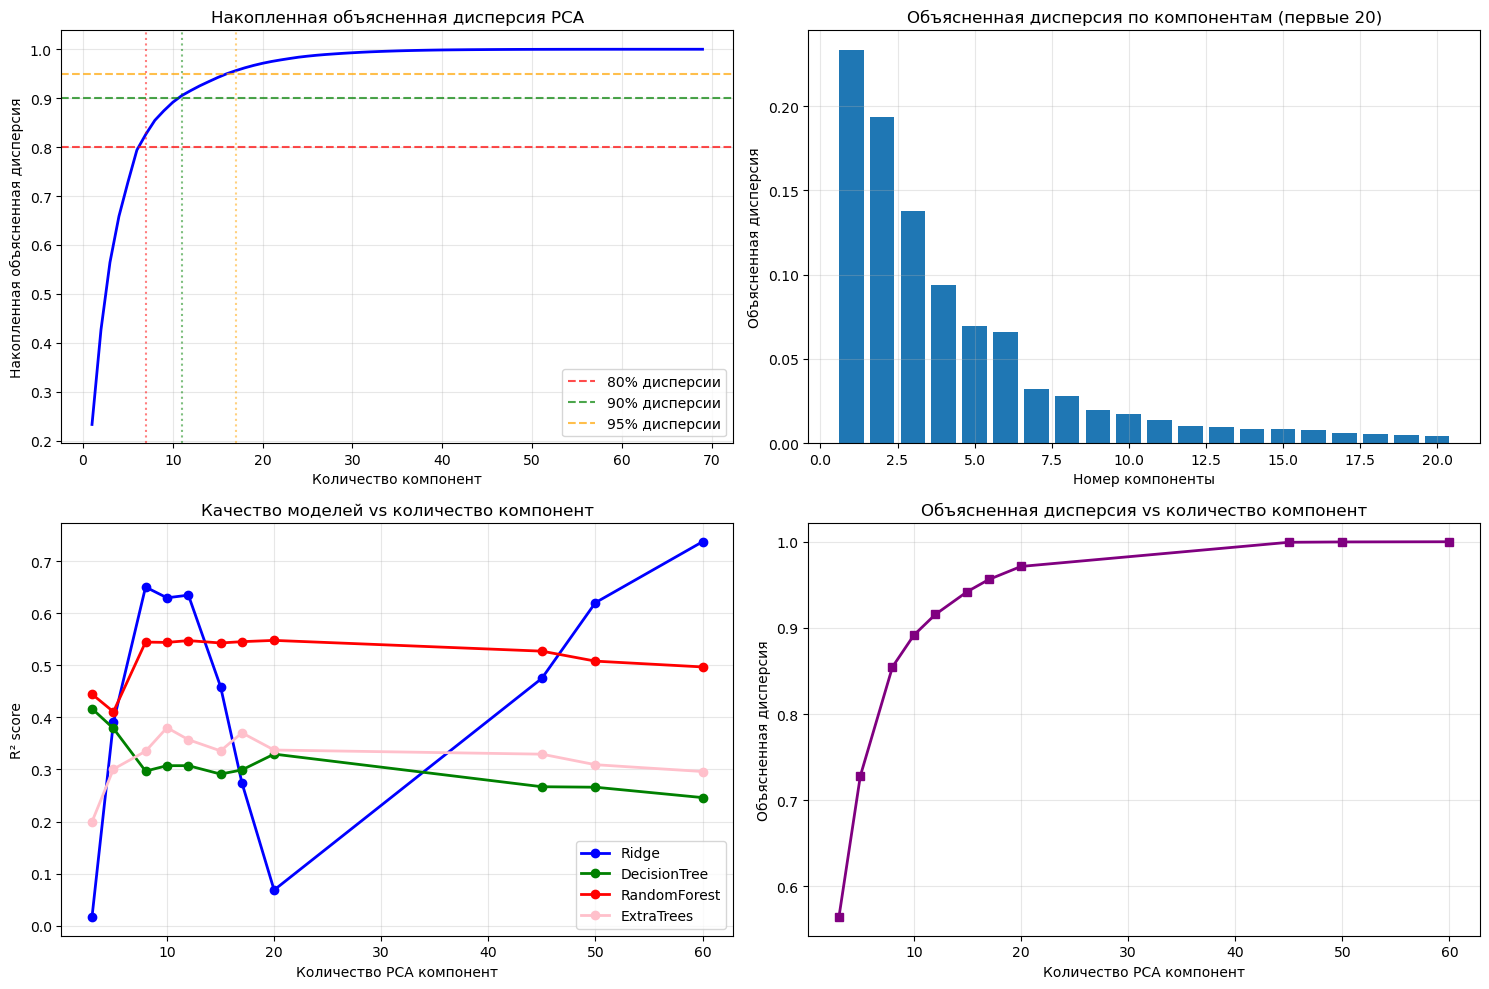


6. АНАЛИЗ ТАРГЕТОВ И PARITY PLOTS
----------------------------------------
Статистика целевой переменной 'a':
  Среднее: 51.536
  Стандартное отклонение: 28.333
  Диапазон: [5.000, 96.000]
  Размах: 91.000
Выбросов в целевой переменной: 0

7. PARITY PLOTS ДЛЯ ЛУЧШЕЙ КОНФИГУРАЦИИ
--------------------------------------------------
Лучшая конфигурация: 60 компонент, Ridge
Parity plot метрики:
  R²: 0.992
  RMSE: 2.552
  MAE: 1.622


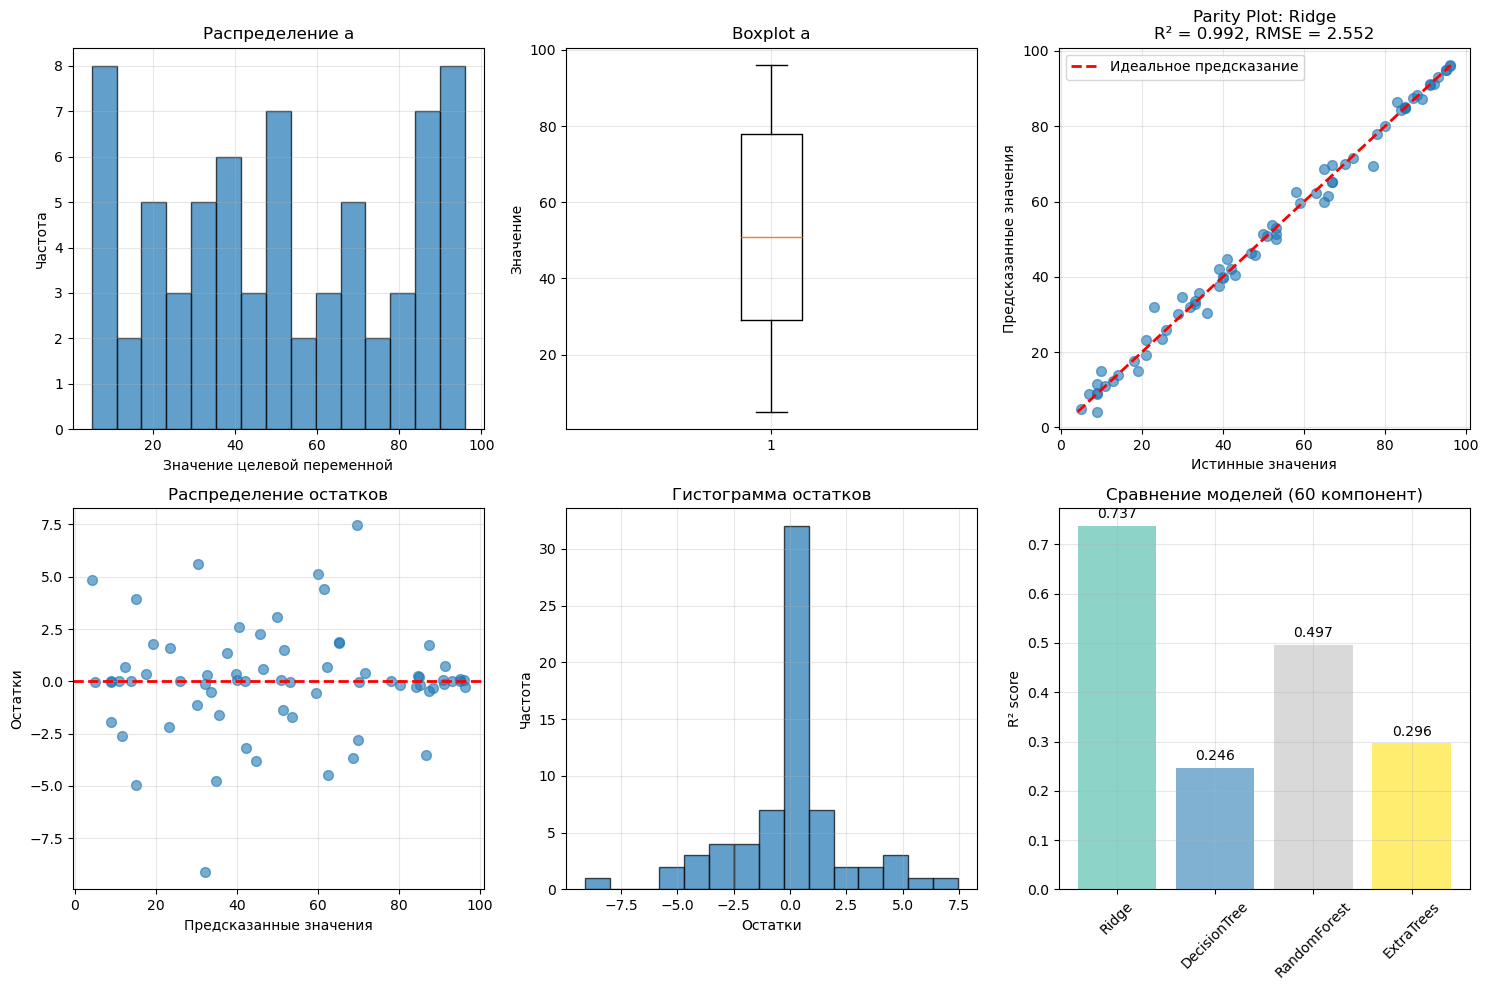


8. АНАЛИЗ ОСТАТКОВ ДЛЯ Ridge
--------------------------------------------------
Статистика остатков:
  Среднее: 0.000 (должно быть ~0)
  Стандартное отклонение: 2.552
  Диапазон: [-9.121, 7.459]
  RMS: 2.552
Корреляция предсказаний и остатков: 0.027
  (должна быть близка к 0 для гомоскедастичности)


In [22]:
result = complete_pca_analysis_with_parity(pd.concat([cleaned_df[["a"]], cleaned_df.iloc[:, 5:]], axis = 1), "a", [3, 5, 8, 10, 12, 15, 17, 20, 45, 50, 60])

ПОЛНЫЙ PCA АНАЛИЗ ДЛЯ МАЛОГО НАБОРА ДАННЫХ (69 СТРОК)

1. ПОДГОТОВКА ДАННЫХ
----------------------------------------
Всего строк: 69
Всего признаков: 4122
Целевая переменная: a

2. МАСШТАБИРОВАНИЕ ПРИЗНАКОВ
----------------------------------------
Масштабирование завершено
Среднее после масштабирования: -0.00
Стандартное отклонение: 0.88

3. АНАЛИЗ ОБЪЯСНЕННОЙ ДИСПЕРСИИ PCA
----------------------------------------
Компонент для 80% дисперсии: 7
Компонент для 90% дисперсии: 11
Компонент для 95% дисперсии: 17

4. СРАВНЕНИЕ РАЗЛИЧНЫХ КОЛИЧЕСТВ PCA-КОМПОНЕНТ
--------------------------------------------------

PCA с 35 компонентами:
------------------------------
Объясненная дисперсия: 0.997
  Ridge           | R²: 0.449 ± 0.184
  DecisionTree    | R²: -0.335 ± 0.392
  RandomForest    | R²: 0.317 ± 0.049
  ExtraTrees      | R²: 0.087 ± 0.012

PCA с 38 компонентами:
------------------------------
Объясненная дисперсия: 0.998
  Ridge           | R²: 0.523 ± 0.089
  DecisionTree    | R²: -0.13

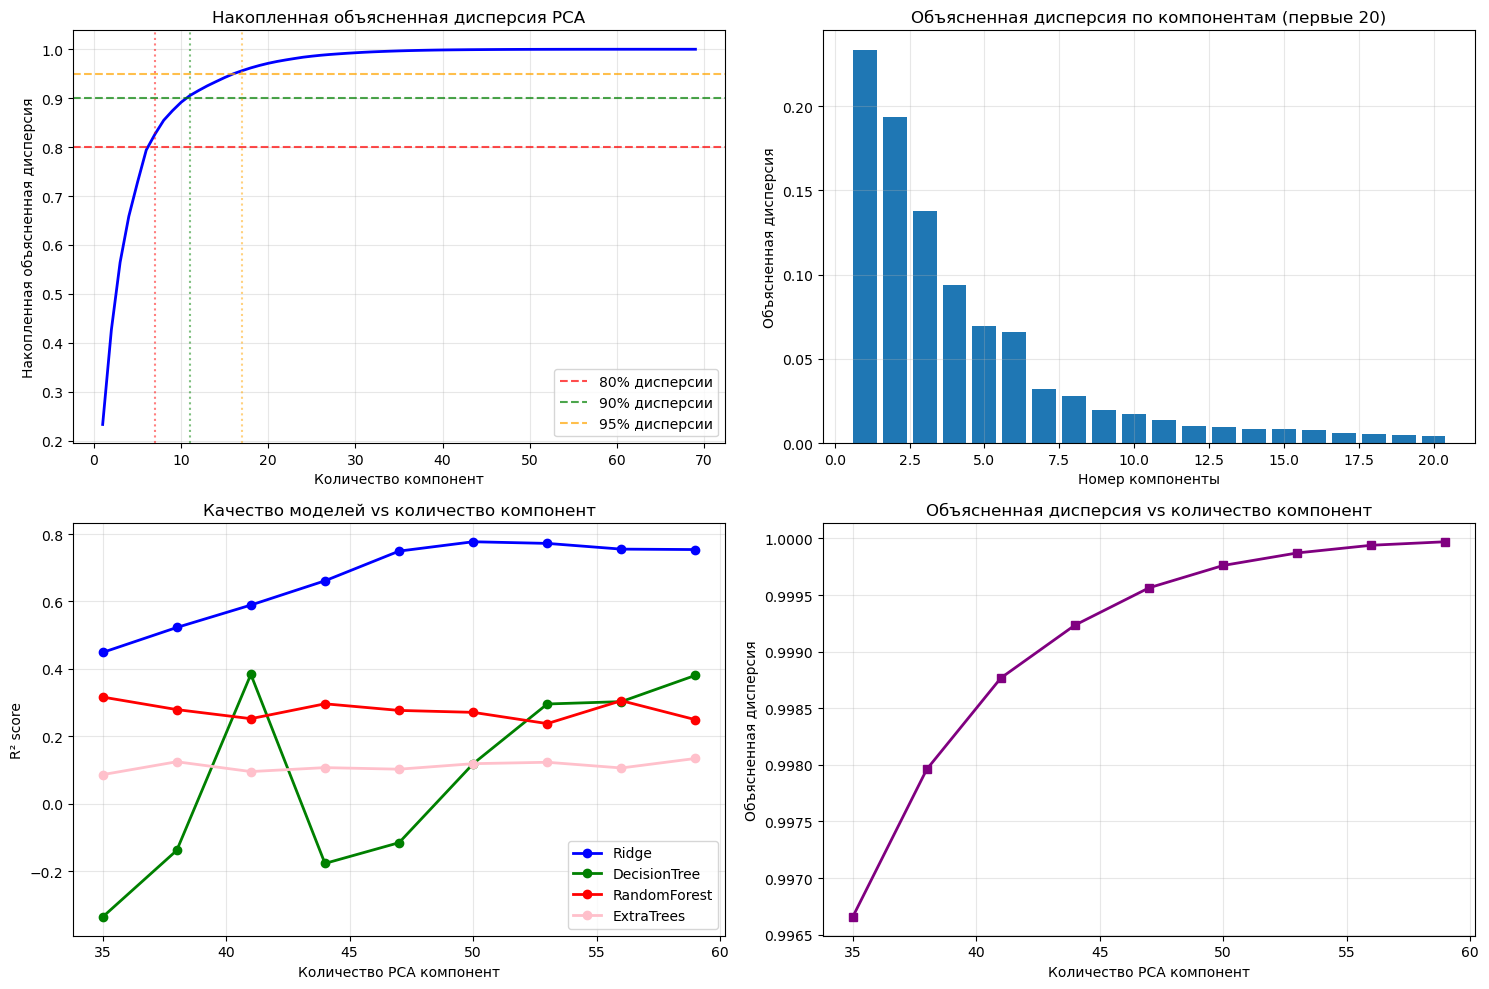


6. АНАЛИЗ ТАРГЕТОВ И PARITY PLOTS
----------------------------------------
Статистика целевой переменной 'a':
  Среднее: 51.536
  Стандартное отклонение: 28.333
  Диапазон: [5.000, 96.000]
  Размах: 91.000
Выбросов в целевой переменной: 0

7. PARITY PLOTS ДЛЯ ЛУЧШЕЙ КОНФИГУРАЦИИ
--------------------------------------------------
Лучшая конфигурация: 50 компонент, Ridge
Parity plot метрики:
  R²: 0.986
  RMSE: 3.347
  MAE: 2.241


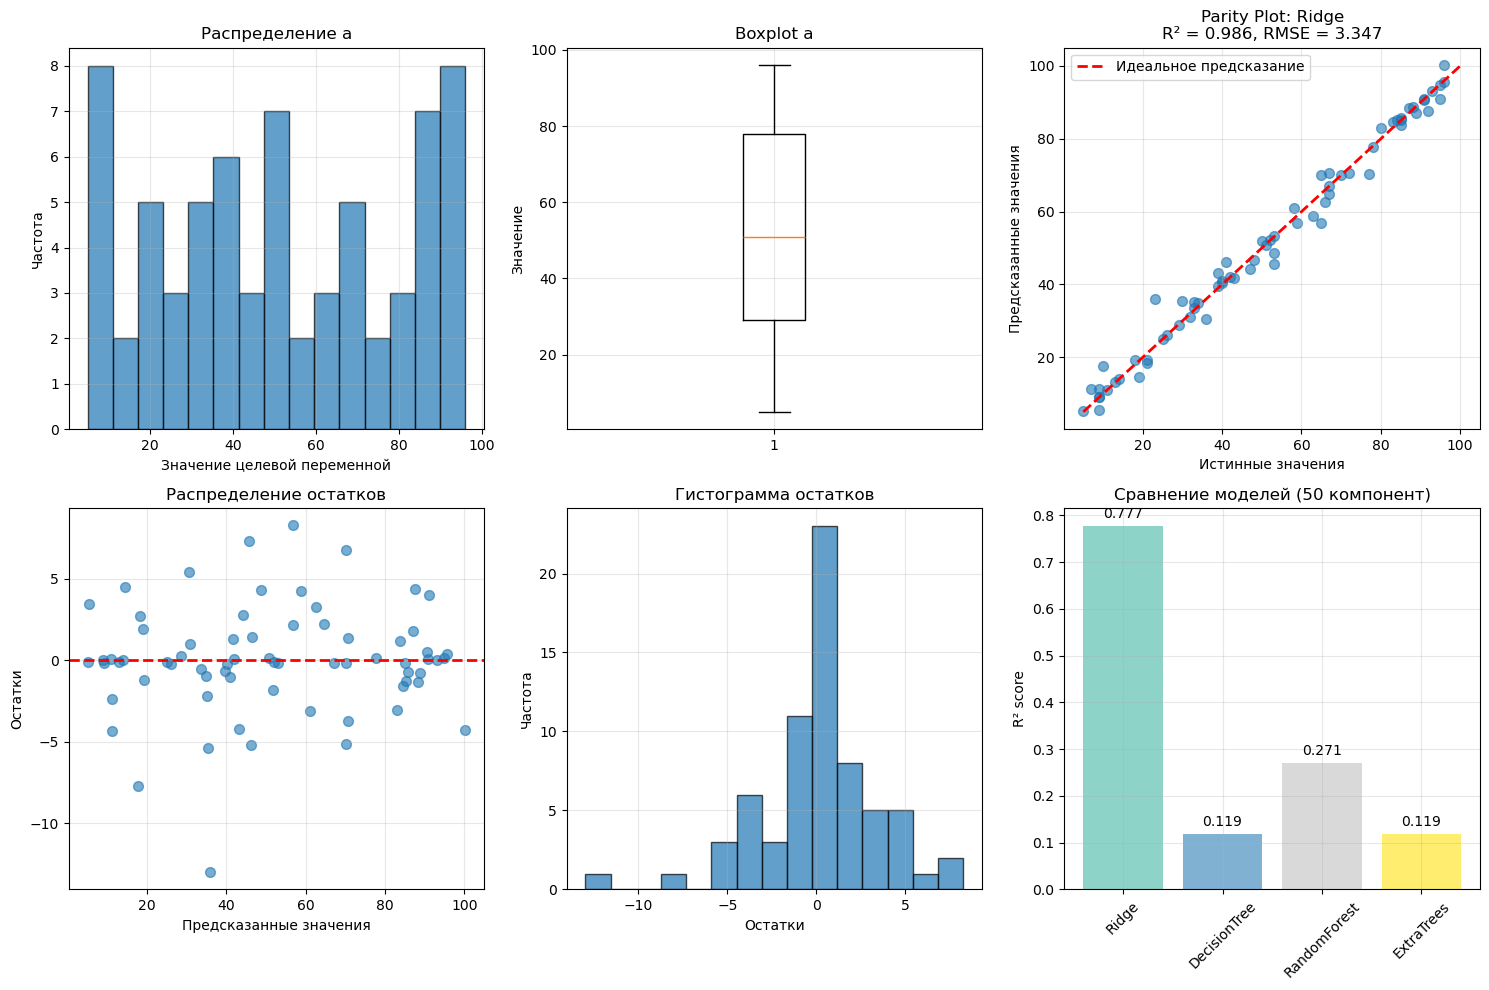


8. АНАЛИЗ ОСТАТКОВ ДЛЯ Ridge
--------------------------------------------------
Статистика остатков:
  Среднее: 0.000 (должно быть ~0)
  Стандартное отклонение: 3.347
  Диапазон: [-12.983, 8.265]
  RMS: 3.347
Корреляция предсказаний и остатков: 0.058
  (должна быть близка к 0 для гомоскедастичности)


In [32]:
result = complete_pca_analysis_with_parity2(pd.concat([cleaned_df[["a"]], cleaned_df.iloc[:, 5:]], axis = 1), "a", [i for i in range(35, 60, 3)])